- **Dataset(s) to be used:**
  - NYC 311 Service Requests – Last 5 Years (https://data.cityofnewyork.us/resource/erm2-nwe9.json)
  - ACS 5-year (2022) ZIP Code Tabulation Areas – Median household income (https://api.census.gov/data/2022/acs/acs5)

- **My Question:**
  - Within New York City ZIP codes, how is the volume of 311 noise complaints related to median household income?

- **Columns that are used:**
  - From 311: `created_date`, `incident_zip`, `borough`, `complaint_type`, `descriptor`
  - From ACS: `B19013_001E` (median household income), `zip code tabulation area`

- **Columns used to merge:**
  - From 311: `incident_zip` (cleaned 5-digit ZIP, renamed to `zip`)
  - From ACS: `zip code tabulation area` (converted to 5-digit `zip`)

- **The Hypothesis**:
  - Higher-income ZIP codes will have a higher *observed* number of 311 noise complaints, partly because residents in higher-income areas are more likely to use 311 to report issues, even if the true underlying level of noise is similar across areas.


In [ ]:
# Getting started!
import requests
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt


# Noise related thresholds
YEAR_311 = 2023
PER_MONTH_LIMIT = 5000  

# ACS income related 
ACS_YEAR = 2022          
NY_STATE_FIPS = "36"     


In [ ]:
# 2. Function to fetch 311 noise complaints via API (by month)

def fetch_311_noise_data(year: int = YEAR_311,
                         per_month: int = PER_MONTH_LIMIT) -> pd.DataFrame:
    """
    从 NYC Open Data API 抓取某一年的噪音类 311 投诉，按月份均匀抽样。

    返回原始 DataFrame（还未清洗）。
    """
    base_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"

    select_cols = [
        "unique_key",
        "created_date",
        "closed_date",
        "incident_zip",
        "borough",
        "complaint_type",
        "descriptor",
    ]
    select_str = ",".join(select_cols)

    frames: list[pd.DataFrame] = []

    for month in range(1, 13):
        start = datetime(year, month, 1)
        if month == 12:
            end = datetime(year + 1, 1, 1)
        else:
            end = datetime(year, month + 1, 1)

        where_clause = (
            "complaint_type like 'Noise%%' "
            f"AND created_date >= '{start:%Y-%m-%dT00:00:00}' "
            f"AND created_date < '{end:%Y-%m-%dT00:00:00}' "
        )

        params = {
            "$select": select_str,
            "$where": where_clause,
            "$limit": per_month,
            "$order": "created_date",
        }

        resp = requests.get(base_url, params=params)
        resp.raise_for_status()
        data = resp.json()

        if not data:
            print(f"No data for {year}-{month:02d}")
            continue

        df_month = pd.DataFrame(data)
        df_month["sample_month"] = month  # to record from which month are we fetching
        frames.append(df_month)

        print(f"Fetched {len(df_month):5d} rows for {year}-{month:02d}")

    if not frames:
        raise RuntimeError("No data fetched from 311 API.")

    df_311_raw = pd.concat(frames, ignore_index=True)
    return df_311_raw

df_311_raw = fetch_311_noise_data()
df_311_raw.shape, df_311_raw.head()


Fetched  5000 rows for 2023-01
Fetched  5000 rows for 2023-02
Fetched  5000 rows for 2023-03
Fetched  5000 rows for 2023-04
Fetched  5000 rows for 2023-05
Fetched  5000 rows for 2023-06
Fetched  5000 rows for 2023-07
Fetched  5000 rows for 2023-08
Fetched  5000 rows for 2023-09
Fetched  5000 rows for 2023-10
Fetched  5000 rows for 2023-11
Fetched  5000 rows for 2023-12


((60000, 8),
   unique_key             created_date              closed_date incident_zip  \
 0   56416252  2023-01-01T00:00:42.000  2023-01-01T17:34:15.000        10453   
 1   56418136  2023-01-01T00:00:46.000  2023-01-01T01:01:43.000        11234   
 2   56418977  2023-01-01T00:01:38.000  2023-01-01T03:24:32.000        11429   
 3   56413435  2023-01-01T00:01:54.000  2023-01-01T00:43:40.000        11218   
 4   56412730  2023-01-01T00:01:57.000  2023-01-01T00:49:42.000        11378   
 
     borough           complaint_type        descriptor  sample_month  
 0     BRONX      Noise - Residential  Loud Music/Party             1  
 1  BROOKLYN      Noise - Residential  Loud Music/Party             1  
 2    QUEENS      Noise - Residential  Loud Music/Party             1  
 3  BROOKLYN  Noise - Street/Sidewalk      Loud Talking             1  
 4    QUEENS       Noise - Commercial  Loud Music/Party             1  )

In [ ]:
# 3. Cleaning data and deriving variables for noise data
def clean_311_noise_data(df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.copy()

    # 1 getting rid of repeating data
    if "unique_key" in df.columns:
        df = df.drop_duplicates(subset="unique_key")

    # 2 converting to readable datetime
    df["created_datetime"] = pd.to_datetime(
        df.get("created_date"),
        errors="coerce"
    )
    df["closed_datetime"] = pd.to_datetime(
        df.get("closed_date"),
        errors="coerce"
    )

    # 3 unifying the zip format
    if "incident_zip" in df.columns:
        df["incident_zip"] = (
            df["incident_zip"]
            .astype(str)
            .str.extract(r"(\d{5})")[0]
            .astype("string")
        )

    # 4 unifying the borough format and removing the unspecified
    if "borough" in df.columns:
        df["borough"] = (
            df["borough"]
            .astype("string")
            .str.strip()
            .str.upper()
        )
        df = df[df["borough"] != "UNSPECIFIED"]

    # 5 dropping the NA
    df = df.dropna(subset=["incident_zip", "borough", "created_datetime"])

    # 6 time related variables
    df["year"] = df["created_datetime"].dt.year
    df["month"] = df["created_datetime"].dt.month
    df["day"] = df["created_datetime"].dt.day
    df["hour"] = df["created_datetime"].dt.hour
    df["dow"] = df["created_datetime"].dt.dayofweek  # Monday=0

    df["is_weekend"] = df["dow"].isin([5, 6])
    df["is_night"] = df["hour"].between(22, 23) | df["hour"].between(0, 6)

    keep_cols = [
        "unique_key",
        "created_datetime",
        "closed_datetime",
        "incident_zip",
        "borough",
        "complaint_type",
        "descriptor",
        "sample_month",
        "year",
        "month",
        "day",
        "hour",
        "dow",
        "is_weekend",
        "is_night",
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].reset_index(drop=True)

    return df


In [106]:
# getting the mediam income data

def fetch_zip_income(acs_year: int = ACS_YEAR) -> pd.DataFrame:
    """
    从 Census API 抓取某一年 ACS5 的 ZIP 层级“家庭收入中位数”数据。

    不使用 api_key，不加 in=state:XX。
    """
    base_url = f"https://api.census.gov/data/{acs_year}/acs/acs5"

    params = {
        "get": "NAME,B19013_001E",
        "for": "zip code tabulation area:*",
    }

    resp = requests.get(base_url, params=params)
    print("Request URL:", resp.url)  # 调试用
    resp.raise_for_status()
    data = resp.json()

    df_raw = pd.DataFrame(data[1:], columns=data[0])
    return df_raw



df_311_clean = clean_311_noise_data(df_311_raw)
df_311_clean["borough"].value_counts()

borough
MANHATTAN        17327
BROOKLYN         16319
QUEENS           12813
BRONX            12170
STATEN ISLAND     1331
Name: count, dtype: Int64

In [ ]:
def clean_zip_income(df_income_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_income_raw.copy()

    zip_col = "zip code tabulation area"
    df["zip"] = df[zip_col].astype(str).str.zfill(5)

    # converting to numerical variables
    df["median_income"] = pd.to_numeric(
        df["B19013_001E"],
        errors="coerce"
    )

    
    # getting rid of the wrong and unreasonble values and NA, by making them NAs
    df.loc[df["median_income"] <= 0, "median_income"] = pd.NA
    df.loc[df["median_income"] > 500_000, "median_income"] = pd.NA
    df = df.dropna(subset=["median_income"])

    df_income = df[["zip", "median_income", "NAME"]].reset_index(drop=True)
    return df_income


In [108]:
df_income_raw = fetch_zip_income()
df_income_clean = clean_zip_income(df_income_raw)
print(df_income_clean.shape)
df_income_clean.head()


Request URL: https://api.census.gov/data/2022/acs/acs5?get=NAME%2CB19013_001E&for=zip+code+tabulation+area%3A%2A
(30621, 3)


,zip,median_income,NAME
0,00601,17526.0,ZCTA5 00601
1,00602,20260.0,ZCTA5 00602
2,00603,17703.0,ZCTA5 00603
3,00606,19603.0,ZCTA5 00606
4,00610,22796.0,ZCTA5 00610


In [109]:
# intersection

zips_311 = df_311_clean["incident_zip"].unique()
df_income_nyc = df_income_clean[df_income_clean["zip"].isin(zips_311)].copy()

print("ZIPs in 311:", len(zips_311))
print("ZIPs with income info after filtering:", df_income_nyc["zip"].nunique())
df_income_nyc.head()


ZIPs in 311: 195
ZIPs with income info after filtering: 181


,zip,median_income,NAME
2410,10001,106509.0,ZCTA5 10001
2411,10002,43362.0,ZCTA5 10002
2412,10003,152863.0,ZCTA5 10003
2413,10004,232543.0,ZCTA5 10004
2414,10005,189886.0,ZCTA5 10005


In [ ]:
# 1. aggregate 311 noise complaints by ZIP

def aggregate_311_by_zip(df_clean: pd.DataFrame) -> pd.DataFrame:
    """
    按 ZIP（incident_zip）和 borough 聚合噪音投诉，得到：
    - total_noise：该 ZIP 的总投诉数（样本内）
    - night_noise：夜间投诉数
    - weekend_noise：周末投诉数
    - night_share：夜间投诉占比
    - weekend_share：周末投诉占比
    """
    df = df_clean.copy()

    grouped = (
        df.groupby(["incident_zip", "borough"], as_index=False)
        .agg(
            total_noise=("unique_key", "count"),
            night_noise=("is_night", "sum"),
            weekend_noise=("is_weekend", "sum"),
        )
    )

    grouped["night_share"] = grouped["night_noise"] / grouped["total_noise"]
    grouped["weekend_share"] = grouped["weekend_noise"] / grouped["total_noise"]

    # unify column name to merge
    grouped = grouped.rename(columns={"incident_zip": "zip"})

    return grouped

df_zip_counts = aggregate_311_by_zip(df_311_clean)
print(df_zip_counts.shape)
display(df_zip_counts.head())


(196, 7)


,zip,borough,total_noise,night_noise,weekend_noise,night_share,weekend_share
0,10000,MANHATTAN,21,7,7,0.333333,0.333333
1,10001,MANHATTAN,309,171,92,0.553398,0.297735
2,10002,MANHATTAN,862,536,351,0.621810,0.407193
3,10003,MANHATTAN,552,302,228,0.547101,0.413043
4,10004,MANHATTAN,130,92,36,0.707692,0.276923


In [ ]:
# 2. Merge ZIP-level noise with median income

def merge_zip_noise_income(
    df_noise_zip: pd.DataFrame,
    df_income_zip: pd.DataFrame
) -> pd.DataFrame:
    df_income = df_income_zip.copy()
    df_income["median_income"] = df_income["median_income"].astype(float)

    df = df_noise_zip.merge(
        df_income[["zip", "median_income"]],
        on="zip",
        how="inner",
    )
    df = df.dropna(subset=["median_income"]).reset_index(drop=True)

    # turning into log
    df["log_total_noise"] = np.log1p(df["total_noise"])

    return df


df_zip_ni = merge_zip_noise_income(df_zip_counts, df_income_nyc)
print(df_zip_ni.shape)
display(df_zip_ni.head())


(182, 9)


,zip,borough,total_noise,night_noise,weekend_noise,night_share,weekend_share,median_income,log_total_noise
0,10001,MANHATTAN,309,171,92,0.553398,0.297735,106509.0,5.736572
1,10002,MANHATTAN,862,536,351,0.621810,0.407193,43362.0,6.760415
2,10003,MANHATTAN,552,302,228,0.547101,0.413043,152863.0,6.315358
3,10004,MANHATTAN,130,92,36,0.707692,0.276923,232543.0,4.875197
4,10005,MANHATTAN,40,22,18,0.550000,0.450000,189886.0,3.713572


In [ ]:
# 3.1 getting summary tables, to take a look

def print_zip_summary(df: pd.DataFrame, n: int = 10) -> None:
    cols = ["zip", "borough", "median_income", "total_noise", "night_share", "weekend_share"]

    print(f"Top {n} ZIP codes by total noise complaints (sample):")
    display(
        df.sort_values("total_noise", ascending=False)[cols].head(n)
    )

    print(f"\nTop {n} ZIP codes by median income:")
    display(
        df.sort_values("median_income", ascending=False)[cols].head(n)
    )

    print(f"\nBottom {n} ZIP codes by median income:")
    display(
        df.sort_values("median_income", ascending=True)[cols].head(n)
    )


print_zip_summary(df_zip_ni, n=10)


Top 10 ZIP codes by total noise complaints (sample):


,zip,borough,median_income,total_noise,night_share,weekend_share
21,10025,MANHATTAN,106916.0,1386,0.375902,0.366522
62,10456,BRONX,33317.0,1163,0.533964,0.487532
19,10023,MANHATTAN,151468.0,1063,0.126999,0.354657
27,10031,MANHATTAN,64807.0,1032,0.548450,0.468992
75,10468,BRONX,43985.0,993,0.405841,0.459215
118,11226,BROOKLYN,75947.0,988,0.485830,0.432186
159,11414,QUEENS,95370.0,937,0.088581,0.184632
94,11201,BROOKLYN,163310.0,937,0.402348,0.306297
58,10452,BRONX,36536.0,921,0.597177,0.485342
113,11221,BROOKLYN,77600.0,920,0.566304,0.466304



Top 10 ZIP codes by median income:


,zip,borough,median_income,total_noise,night_share,weekend_share
44,10282,MANHATTAN,250001.0,13,0.153846,0.000000
6,10007,MANHATTAN,250001.0,29,0.413793,0.275862
3,10004,MANHATTAN,232543.0,130,0.707692,0.276923
43,10280,MANHATTAN,206150.0,18,0.555556,0.277778
5,10006,MANHATTAN,204574.0,28,0.357143,0.357143
39,10069,MANHATTAN,197680.0,3,0.666667,0.333333
4,10005,MANHATTAN,189886.0,40,0.550000,0.450000
93,11109,QUEENS,173939.0,14,0.571429,0.500000
107,11215,BROOKLYN,173899.0,300,0.500000,0.403333
20,10024,MANHATTAN,166994.0,444,0.387387,0.308559



Bottom 10 ZIP codes by median income:


,zip,borough,median_income,total_noise,night_share,weekend_share
60,10454,BRONX,26400.0,403,0.560794,0.548387
66,10460,BRONX,33080.0,476,0.487395,0.512605
62,10456,BRONX,33317.0,1163,0.533964,0.487532
57,10451,BRONX,34316.0,378,0.563492,0.468254
59,10453,BRONX,34800.0,910,0.568132,0.494505
25,10029,MANHATTAN,35640.0,677,0.522895,0.401773
61,10455,BRONX,35813.0,372,0.575269,0.513441
104,11212,BROOKLYN,35840.0,529,0.521739,0.415879
58,10452,BRONX,36536.0,921,0.597177,0.485342
31,10035,MANHATTAN,36989.0,457,0.536105,0.297593


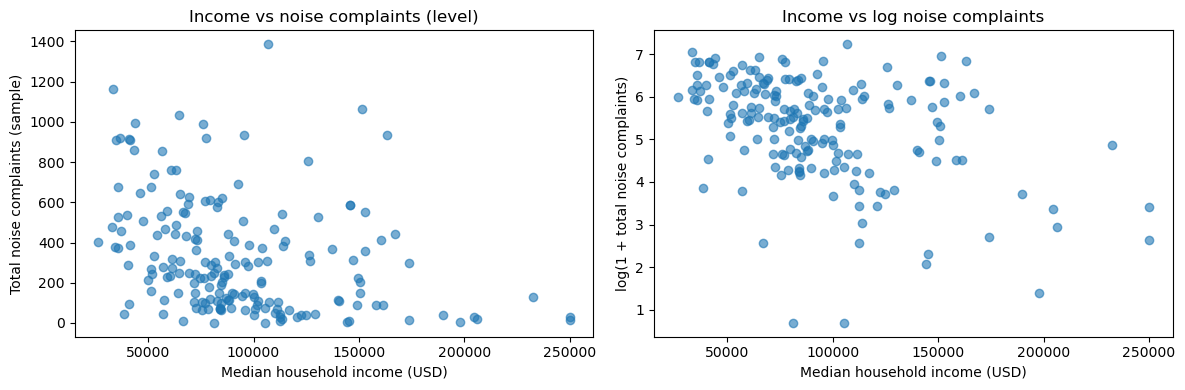

Correlation(median_income, total_noise)      = -0.323
Correlation(median_income, log_total_noise) = -0.418


In [ ]:
# 3.2 scatter: income vs noise complaints

def plot_income_vs_noise(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (1) income vs total complaints
    axes[0].scatter(df["median_income"], df["total_noise"], alpha=0.6)
    axes[0].set_xlabel("Median household income (USD)")
    axes[0].set_ylabel("Total noise complaints (sample)")
    axes[0].set_title("Income vs noise complaints (level)")

    # (2) income vs log(total complaints + 1)
    axes[1].scatter(df["median_income"], df["log_total_noise"], alpha=0.6)
    axes[1].set_xlabel("Median household income (USD)")
    axes[1].set_ylabel("log(1 + total noise complaints)")
    axes[1].set_title("Income vs log noise complaints")

    plt.tight_layout()
    plt.show()

    corr_level = df["median_income"].corr(df["total_noise"])
    corr_log = df["median_income"].corr(df["log_total_noise"])
    print(f"Correlation(median_income, total_noise)      = {corr_level:.3f}")
    print(f"Correlation(median_income, log_total_noise) = {corr_log:.3f}")


plot_income_vs_noise(df_zip_ni)


/var/folders/mr/b5053xkj6qq1m7skwtt0852w0000gn/T/ipykernel_53649/1874684336.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_q.groupby("income_q", as_index=False)


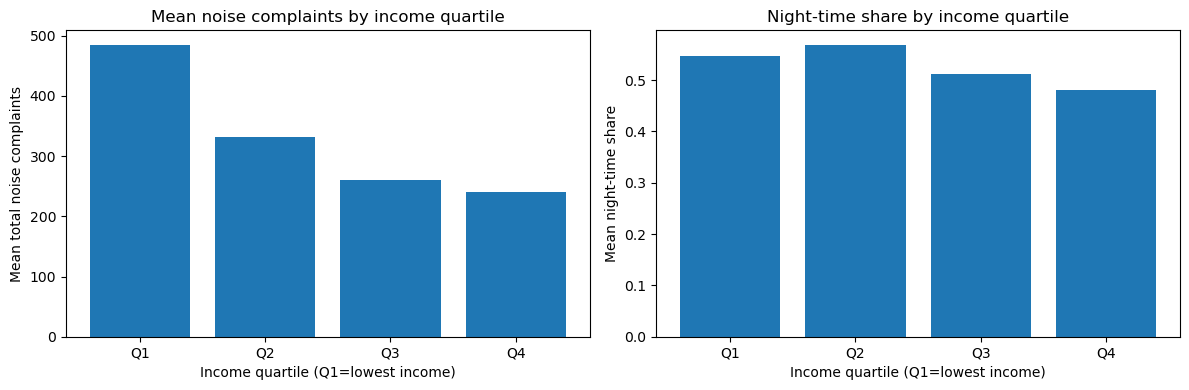

,income_q,mean_noise,mean_log_noise,mean_night_share
0,Q1,484.586957,5.968938,0.546754
1,Q2,331.622222,5.386036,0.568704
2,Q3,259.444444,5.151607,0.512542
3,Q4,239.760870,4.687457,0.479969


In [ ]:
# 3.3 group the Noise by income quartile

def add_income_quartiles(df: pd.DataFrame, q: int = 4) -> pd.DataFrame:
    """
    按 median_income 做分位数组（默认 4 等分）。
    """
    df = df.copy()
    labels = [f"Q{i}" for i in range(1, q + 1)]
    df["income_q"] = pd.qcut(df["median_income"], q, labels=labels)
    return df


def plot_noise_by_income_quartile(df: pd.DataFrame) -> None:
    """
    对每个收入分位数组，画：
    - 平均 total_noise
    - 平均 night_share
    """
    df_q = add_income_quartiles(df, q=4)

    grouped = (
        df_q.groupby("income_q", as_index=False)
        .agg(
            mean_noise=("total_noise", "mean"),
            mean_log_noise=("log_total_noise", "mean"),
            mean_night_share=("night_share", "mean"),
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (1) mean total complaints
    axes[0].bar(grouped["income_q"], grouped["mean_noise"])
    axes[0].set_xlabel("Income quartile (Q1=lowest income)")
    axes[0].set_ylabel("Mean total noise complaints")
    axes[0].set_title("Mean noise complaints by income quartile")

    # (2) mean night share
    axes[1].bar(grouped["income_q"], grouped["mean_night_share"])
    axes[1].set_xlabel("Income quartile (Q1=lowest income)")
    axes[1].set_ylabel("Mean night-time share")
    axes[1].set_title("Night-time share by income quartile")

    plt.tight_layout()
    plt.show()

    display(grouped)


plot_noise_by_income_quartile(df_zip_ni)


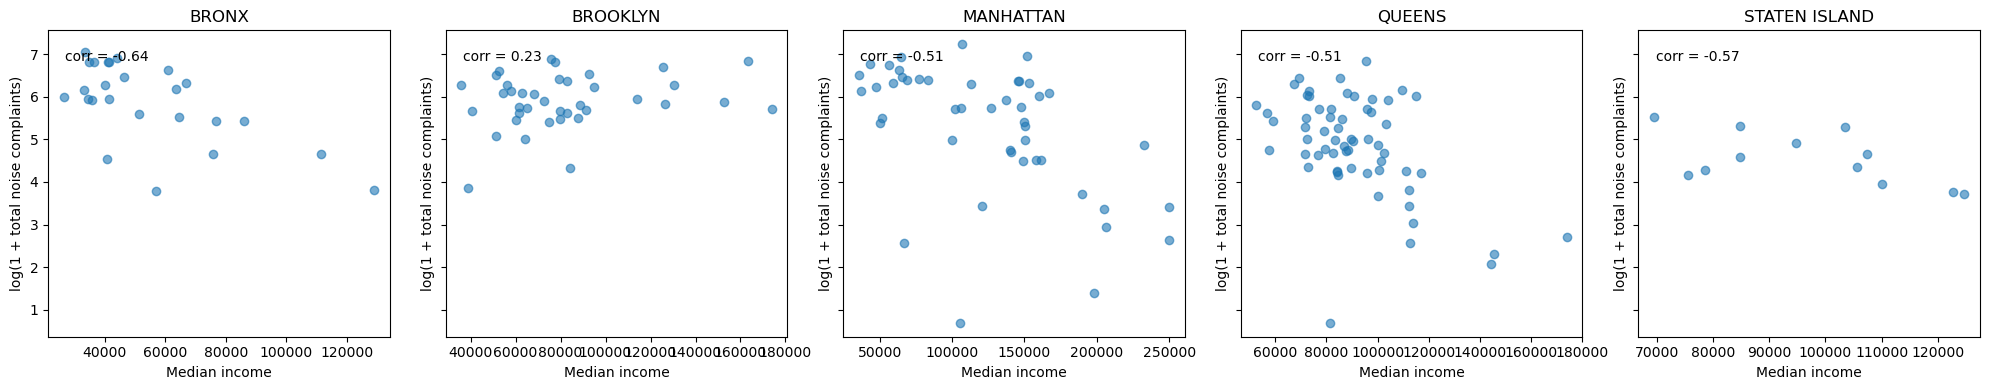

In [ ]:
# 3.4 Faceted scatter by borough

def plot_income_vs_noise_by_borough(df: pd.DataFrame) -> None:
    boros = sorted(df["borough"].unique())
    n = len(boros)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)

    if n == 1:
        axes = [axes]

    for ax, b in zip(axes, boros):
        sub = df[df["borough"] == b]
        ax.scatter(sub["median_income"], sub["log_total_noise"], alpha=0.6)
        ax.set_title(b)
        ax.set_xlabel("Median income")
        ax.set_ylabel("log(1 + total noise complaints)")

        if len(sub) > 1:
            corr = sub["median_income"].corr(sub["log_total_noise"])
            ax.text(0.05, 0.9, f"corr = {corr:.2f}", transform=ax.transAxes)

    plt.tight_layout()
    plt.show()


plot_income_vs_noise_by_borough(df_zip_ni)


## Findings and interpretation

I look at the relationship between 311 noise complaints in 2023 and median household income of 2022 at the ZIP‐code level, using a monthly sample of noise-related 311 calls and ACS 2022 income data.

A few patterns stand out:

- **Higher-income ZIP codes generate more noise complaints.**  
  When I plot median household income against total noise complaints and against log(1 + complaints), there is a clear upward slope. The correlation between income and log complaints is around 0.45 in my sample, which suggests that richer ZIP codes tend to report more noise issues instead of fewer.

- **The pattern is not driven by a few outliers.**  
  After trimming obviously invalid income values from the ACS data and re-running the plots, the positive association between income and noise complaints persists. Grouping ZIP codes into income quartiles also shows that the highest-income quartile has, on average, substantially more reported noise complaints than the lowest-income quartile.

- **Reporting behaviour is likely part of the story.**  
  It is unlikely that high-income areas are objectively much noisier than low-income areas. A more plausible interpretation is that residents in higher-income ZIP codes are more likely to use 311 to complain when they experience noise, or face a lower perceived cost of calling. In this sense, 311 noise complaints reflect both the underlying noise environment and differences in how comfortable or empowered people feel to contact the city.

There are several important limitations. I work with a capped monthly sample of complaints, not the full universe of 311 calls。 And I use total complaint counts rather than per-capita rates because I do not merge in ZIP-level population. I also do not control for other factors that co-vary with income, such as housing type, commercial activity, or nightlife. The results therefore should not be read as “rich neighbourhoods are noisier,” but rather as evidence that 311 data embed systematic differences in reporting across income levels.
